# Final Project Solution: S&P 500 Historical Data Analysis

This notebook solves the tasks using:

- **Pandas** for loading, preparing, and analyzing the data;
- **Matplotlib** for visualization.


Expected CSV columns:

```text
Date, Open, High, Low, Close
```

## 1. Import the required libraries

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Display settings for more readable tables
pd.set_option("display.float_format", "{:,.2f}".format)

## 2. Load the data

The `skipinitialspace=True` argument removes spaces that may appear after commas in the CSV file.

The date is initially loaded as text. It will be converted explicitly in the data-preparation section.

In [2]:
CSV_PATH = Path("../data/HistoricalPrices.csv")

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"File not found: {CSV_PATH.resolve()}\n"
        "Place HistoricalPrices.csv in the same directory as this notebook."
    )

df = pd.read_csv(CSV_PATH, skipinitialspace=True)

required_columns = {"Date", "Open", "High", "Low", "Close"}
missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        "The CSV file is missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

print(f"Loaded {len(df):,} rows and {len(df.columns)} columns.")

Loaded 11,336 rows and 5 columns.


### First five rows

In [3]:
df.head()

,Date,Open,High,Low,Close
0,12/14/22,"4,015.54","4,053.76","3,965.65","3,995.32"
1,12/13/22,"4,069.38","4,100.96","3,993.03","4,019.65"
2,12/12/22,"3,939.29","3,990.71","3,935.30","3,990.56"
3,12/09/22,"3,954.17","3,977.02","3,933.04","3,934.38"
4,12/08/22,"3,947.79","3,974.19","3,935.83","3,963.51"


### Last five rows

In [4]:
df.tail()

,Date,Open,High,Low,Close
11331,01/09/78,90.64,91.52,90.01,90.64
11332,01/06/78,91.62,92.66,91.05,91.62
11333,01/05/78,92.74,94.53,92.51,92.74
11334,01/04/78,93.52,94.10,93.16,93.52
11335,01/03/78,93.82,95.15,93.49,93.82


### Basic information about the dataset

In [5]:
df.info()

print("\nDataFrame shape:", df.shape)
print("\nColumn data types:")
display(df.dtypes.to_frame(name="dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame(name="missing_values"))

<class 'pandas.DataFrame'>
RangeIndex: 11336 entries, 0 to 11335
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11336 non-null  str    
 1   Open    11336 non-null  float64
 2   High    11336 non-null  float64
 3   Low     11336 non-null  float64
 4   Close   11336 non-null  float64
dtypes: float64(4), str(1)
memory usage: 442.9 KB

DataFrame shape: (11336, 5)

Column data types:


,dtype
Date,str
Open,float64
High,float64
Low,float64
Close,float64



Missing values:


,missing_values
Date,0
Open,0
High,0
Low,0
Close,0


## 3. Prepare the data

The dates in the source file have the format `month/day/two-digit year`, for example `12/14/22`.

The matching Pandas format string is:

```text
%m/%d/%y
```

Specifying the format explicitly avoids ambiguous date parsing.

In [6]:
df["Date"] = pd.to_datetime(
    df["Date"].astype(str).str.strip(),
    format="%m/%d/%y",
    errors="raise",
)

# Make sure the market-value columns are numeric.
numeric_columns = ["Open", "High", "Low", "Close"]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="raise")

df = (
    df
    .set_index("Date")
    .sort_index()
)

# Ensure one row per trading date.
if df.index.has_duplicates:
    duplicate_dates = df.index[df.index.duplicated()].unique()
    raise ValueError(
        "Duplicate trading dates found: "
        + ", ".join(date.strftime("%Y-%m-%d") for date in duplicate_dates[:10])
    )

df.head()

,Open,High,Low,Close
Date,,,,
1978-01-03,93.82,95.15,93.49,93.82
1978-01-04,93.52,94.10,93.16,93.52
1978-01-05,92.74,94.53,92.51,92.74
1978-01-06,91.62,92.66,91.05,91.62
1978-01-09,90.64,91.52,90.01,90.64


### Verify the prepared DataFrame

In [7]:
df.info()

print("\nDate range:")
print("From:", df.index.min().date())
print("To:  ", df.index.max().date())

print("\nIs the index sorted?", df.index.is_monotonic_increasing)

<class 'pandas.DataFrame'>
DatetimeIndex: 11336 entries, 1978-01-03 to 2022-12-14
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    11336 non-null  float64
 1   High    11336 non-null  float64
 2   Low     11336 non-null  float64
 3   Close   11336 non-null  float64
dtypes: float64(4)
memory usage: 442.8 KB

Date range:
From: 1978-01-03
To:   2022-12-14

Is the index sorted? True


## 4. Create additional columns

The project defines `Return` as the percentage change from the opening value to the closing value of the **same trading day**:

```text
Return = (Close - Open) / Open × 100
```

This differs from the commonly used close-to-close return calculated with `Close.pct_change()`.

In [8]:
df["Range"] = df["High"] - df["Low"]
df["Change"] = df["Close"] - df["Open"]
df["Return"] = (df["Close"] - df["Open"]) / df["Open"] * 100

df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()
df["Volatility"] = df["Return"].rolling(window=20).std()

df.head(25)

,Open,High,Low,Close,Range,Change,Return,MA20,MA50,Volatility
Date,,,,,,,,,,
1978-01-03,93.82,95.15,93.49,93.82,1.66,0.00,0.00,NaN,NaN,NaN
1978-01-04,93.52,94.10,93.16,93.52,0.94,0.00,0.00,NaN,NaN,NaN
1978-01-05,92.74,94.53,92.51,92.74,2.02,0.00,0.00,NaN,NaN,NaN
1978-01-06,91.62,92.66,91.05,91.62,1.61,0.00,0.00,NaN,NaN,NaN
1978-01-09,90.64,91.52,90.01,90.64,1.51,0.00,0.00,NaN,NaN,NaN
1978-01-10,90.17,91.29,89.72,90.17,1.57,0.00,0.00,NaN,NaN,NaN
1978-01-11,89.74,90.70,89.74,89.74,0.96,0.00,0.00,NaN,NaN,NaN
1978-01-12,89.92,90.60,89.25,89.92,1.35,0.00,0.00,NaN,NaN,NaN
1978-01-13,89.69,90.47,89.26,89.69,1.21,0.00,0.00,NaN,NaN,NaN


The first values of `MA20`, `MA50`, and `Volatility` are `NaN` because a complete rolling window is not yet available.

## 5. Statistical analysis

In [9]:
summary = pd.Series(
    {
        "Number of trading days": len(df),
        "Highest closing price": df["Close"].max(),
        "Lowest closing price": df["Close"].min(),
        "Average closing price": df["Close"].mean(),
        "Median closing price": df["Close"].median(),
        "Closing price standard deviation": df["Close"].std(),
    },
    name="Value",
)

summary.to_frame()

,Value
Number of trading days,"11,336.00"
Highest closing price,"4,796.56"
Lowest closing price,86.90
Average closing price,"1,147.25"
Median closing price,"1,025.77"
Closing price standard deviation,"1,032.68"


### Days with the most notable movements

In [10]:
largest_gain_date = df["Change"].idxmax()
largest_loss_date = df["Change"].idxmin()
largest_range_date = df["Range"].idxmax()

notable_days = pd.DataFrame(
    {
        "Event": [
            "Largest daily gain",
            "Largest daily loss",
            "Largest trading range",
        ],
        "Date": [
            largest_gain_date,
            largest_loss_date,
            largest_range_date,
        ],
        "Open": [
            df.loc[largest_gain_date, "Open"],
            df.loc[largest_loss_date, "Open"],
            df.loc[largest_range_date, "Open"],
        ],
        "High": [
            df.loc[largest_gain_date, "High"],
            df.loc[largest_loss_date, "High"],
            df.loc[largest_range_date, "High"],
        ],
        "Low": [
            df.loc[largest_gain_date, "Low"],
            df.loc[largest_loss_date, "Low"],
            df.loc[largest_range_date, "Low"],
        ],
        "Close": [
            df.loc[largest_gain_date, "Close"],
            df.loc[largest_loss_date, "Close"],
            df.loc[largest_range_date, "Close"],
        ],
        "Change": [
            df.loc[largest_gain_date, "Change"],
            df.loc[largest_loss_date, "Change"],
            df.loc[largest_range_date, "Change"],
        ],
        "Return (%)": [
            df.loc[largest_gain_date, "Return"],
            df.loc[largest_loss_date, "Return"],
            df.loc[largest_range_date, "Return"],
        ],
        "Range": [
            df.loc[largest_gain_date, "Range"],
            df.loc[largest_loss_date, "Range"],
            df.loc[largest_range_date, "Range"],
        ],
    }
)

notable_days

,Event,Date,Open,High,Low,Close,Change,Return (%),Range
0,Largest daily gain,2022-10-13,"3,520.37","3,685.41","3,491.58","3,669.91",149.54,4.25,193.83
1,Largest daily loss,2020-03-12,"2,630.86","2,660.95","2,478.86","2,480.64",-150.22,-5.71,182.09
2,Largest trading range,2020-03-13,"2,569.99","2,711.33","2,492.37","2,711.02",141.03,5.49,218.96


### Descriptive statistics for the calculated indicators

In [11]:
df[["Range", "Change", "Return", "Volatility"]].describe()

,Range,Change,Return,Volatility
count,"11,336.00","11,336.00","11,336.00","11,317.00"
mean,14.25,0.12,0.01,0.31
std,18.05,13.48,0.63,0.56
min,0.00,-150.22,-8.85,0.00
25%,2.94,0.00,0.00,0.00
50%,9.05,0.00,0.00,0.00
75%,18.31,0.00,0.00,0.53
max,218.96,149.54,7.72,4.48


## 6. Visualizations

### Chart 1: Closing price over time

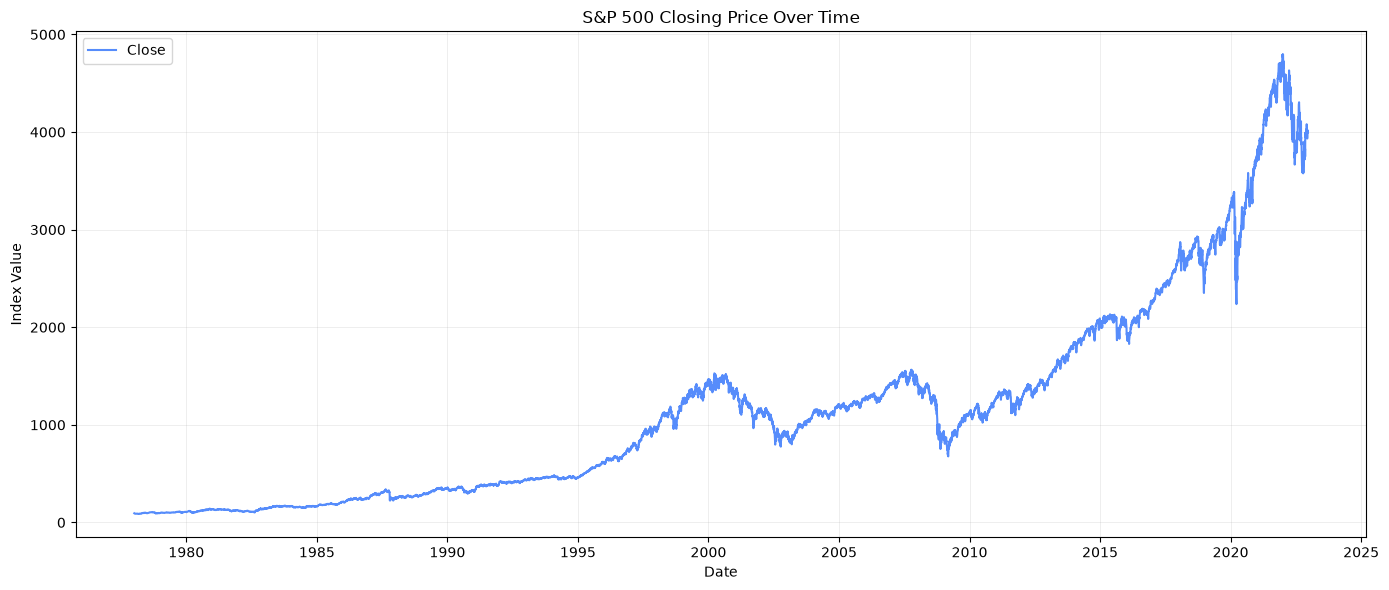

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], label="Close")
plt.title("S&P 500 Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Chart 2: Open and Close prices

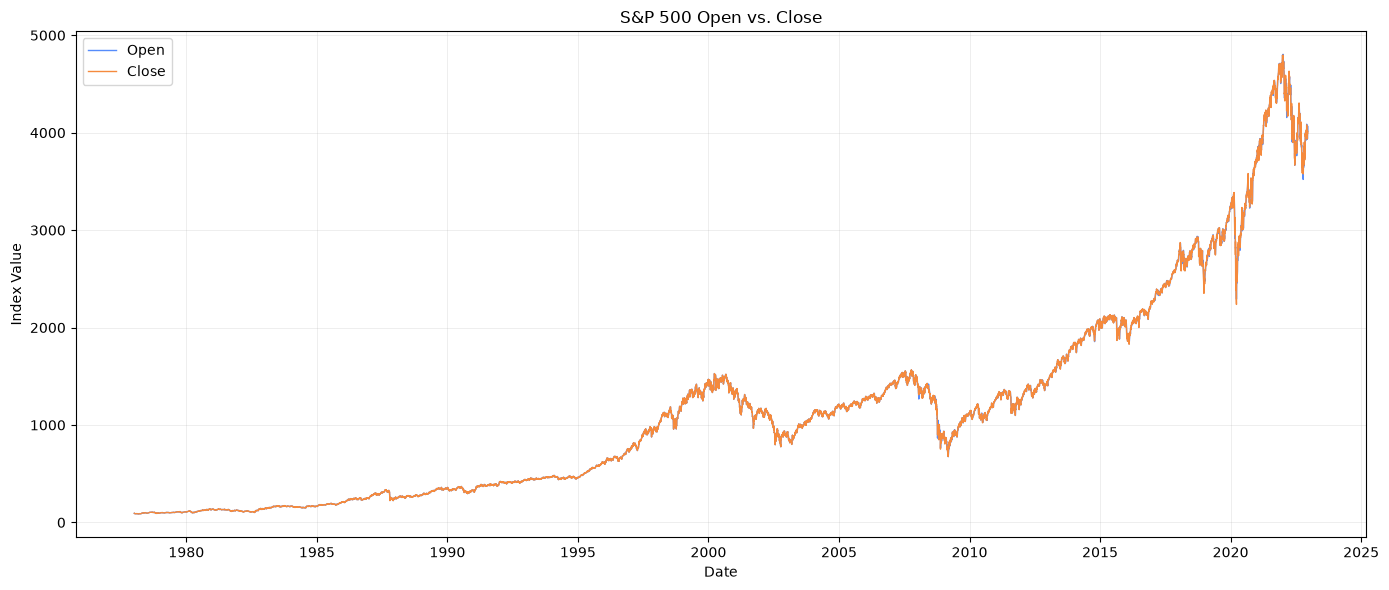

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Open"], label="Open", linewidth=1)
plt.plot(df.index, df["Close"], label="Close", linewidth=1)
plt.title("S&P 500 Open vs. Close")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Chart 3: Distribution of daily intraday returns

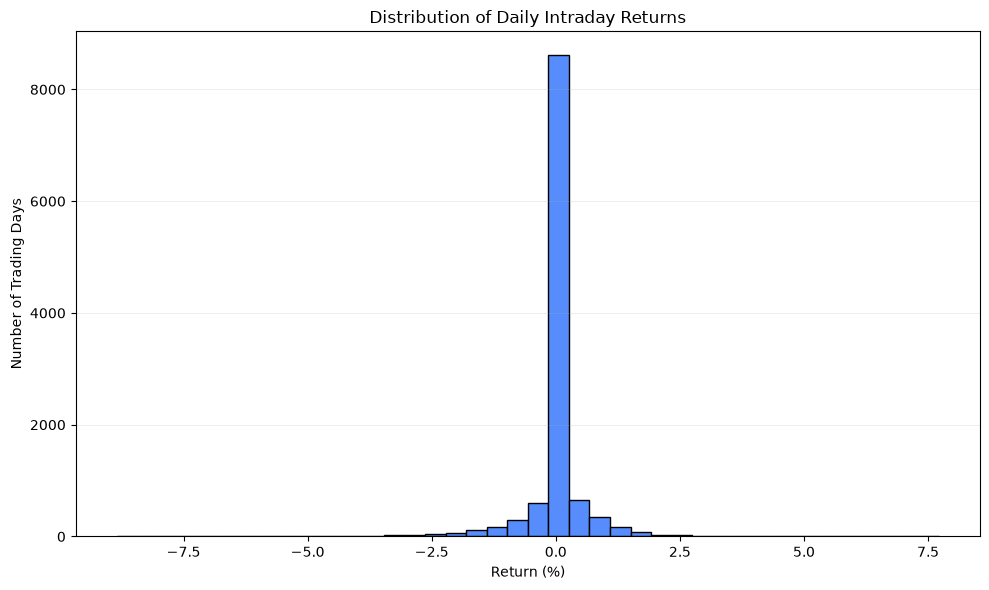

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(df["Return"].dropna(), bins=40, edgecolor="black")
plt.title("Distribution of Daily Intraday Returns")
plt.xlabel("Return (%)")
plt.ylabel("Number of Trading Days")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 4: Closing price with moving averages

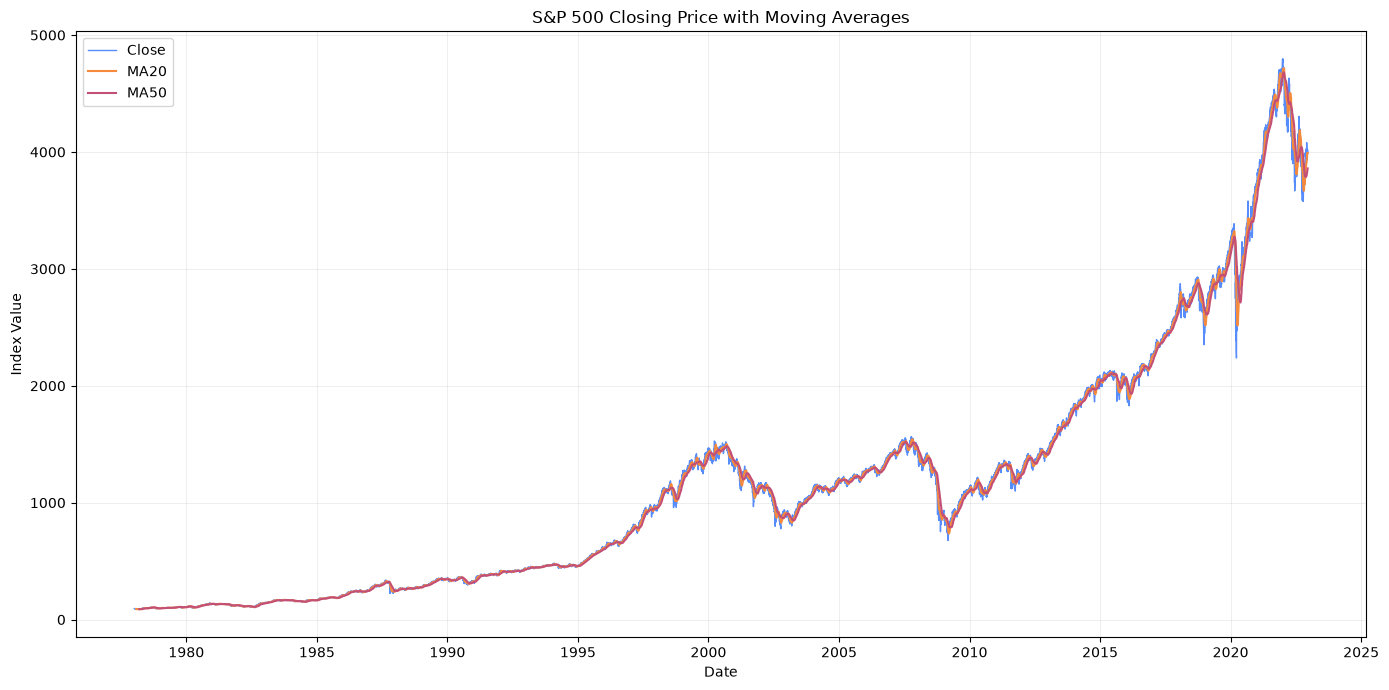

In [15]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, df["Close"], label="Close", linewidth=1)
plt.plot(df.index, df["MA20"], label="MA20", linewidth=1.5)
plt.plot(df.index, df["MA50"], label="MA50", linewidth=1.5)
plt.title("S&P 500 Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Chart 5: 20-day rolling volatility

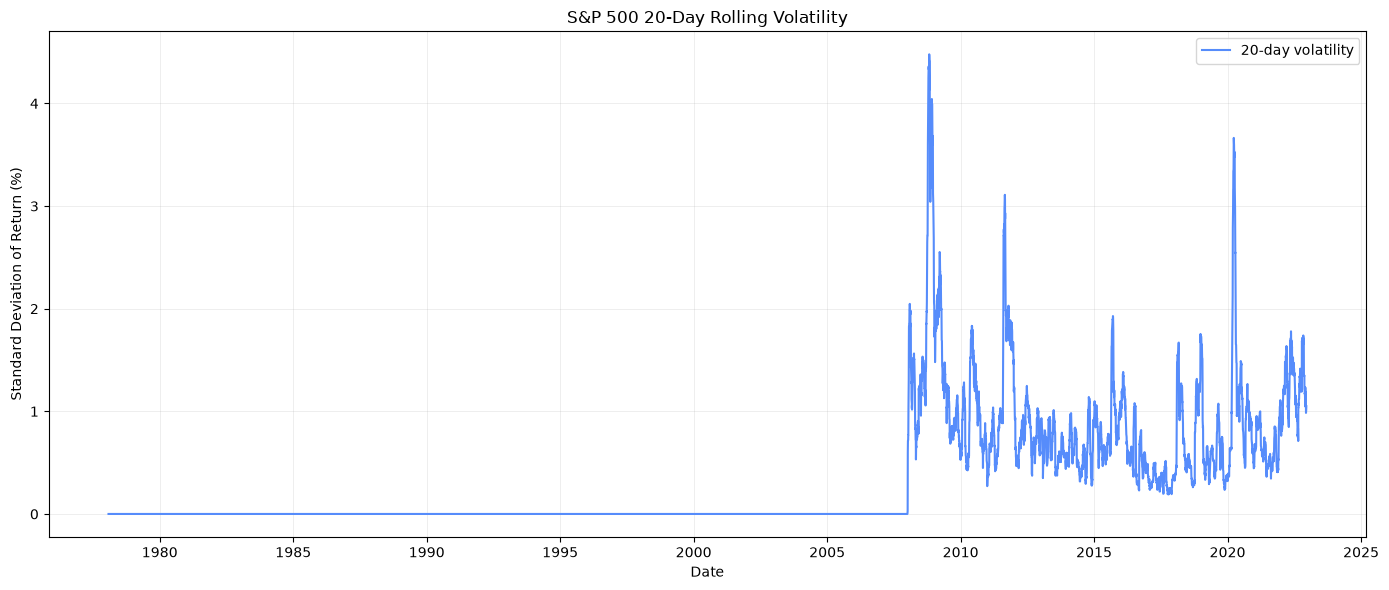

In [16]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Volatility"], label="20-day volatility")
plt.title("S&P 500 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Standard Deviation of Return (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Additional analysis: monthly closing prices

This section is not required by the task, but it demonstrates time-series resampling with Pandas.

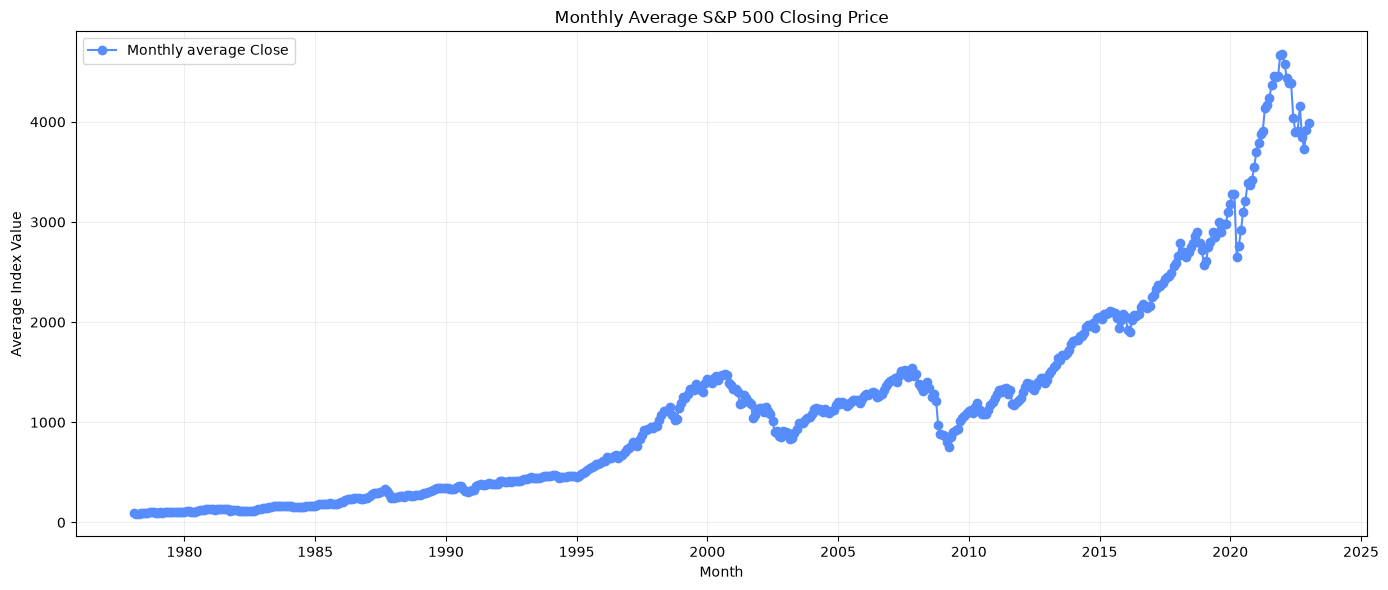

In [17]:
monthly_close = df["Close"].resample("ME").mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_close.index, monthly_close, marker="o", label="Monthly average Close")
plt.title("Monthly Average S&P 500 Closing Price")
plt.xlabel("Month")
plt.ylabel("Average Index Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Automatically generated factual observations

These statements are generated directly from the calculated data. They avoid unsupported interpretations and can be used as the factual basis for the final written conclusion.

In [18]:
start_close = df["Close"].iloc[0]
end_close = df["Close"].iloc[-1]
overall_change_percent = (end_close - start_close) / start_close * 100

highest_close_date = df["Close"].idxmax()
lowest_close_date = df["Close"].idxmin()
highest_volatility_date = df["Volatility"].idxmax()

trend_word = "increased" if overall_change_percent > 0 else "decreased"

print(
    f"1. The dataset contains {len(df):,} trading days from "
    f"{df.index.min().date()} to {df.index.max().date()}."
)
print(
    f"2. The closing value {trend_word} from {start_close:,.2f} "
    f"to {end_close:,.2f}, a change of {overall_change_percent:,.2f}%."
)
print(
    f"3. The highest closing value was {df['Close'].max():,.2f} "
    f"on {highest_close_date.date()}."
)
print(
    f"4. The lowest closing value was {df['Close'].min():,.2f} "
    f"on {lowest_close_date.date()}."
)
print(
    f"5. The largest intraday gain was {df.loc[largest_gain_date, 'Change']:,.2f} "
    f"points on {largest_gain_date.date()}."
)
print(
    f"6. The largest intraday loss was {df.loc[largest_loss_date, 'Change']:,.2f} "
    f"points on {largest_loss_date.date()}."
)
print(
    f"7. The largest trading range was {df.loc[largest_range_date, 'Range']:,.2f} "
    f"points on {largest_range_date.date()}."
)

if pd.notna(highest_volatility_date):
    print(
        f"8. The highest 20-day rolling volatility occurred on "
        f"{highest_volatility_date.date()} and equaled "
        f"{df.loc[highest_volatility_date, 'Volatility']:,.2f}%."
    )

1. The dataset contains 11,336 trading days from 1978-01-03 to 2022-12-14.
2. The closing value increased from 93.82 to 3,995.32, a change of 4,158.49%.
3. The highest closing value was 4,796.56 on 2022-01-03.
4. The lowest closing value was 86.90 on 1978-03-06.
5. The largest intraday gain was 149.54 points on 2022-10-13.
6. The largest intraday loss was -150.22 points on 2020-03-12.
7. The largest trading range was 218.96 points on 2020-03-13.
8. The highest 20-day rolling volatility occurred on 2008-10-28 and equaled 4.48%.
